In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import torch
import torch.nn as nn   
import torch.optim as optim

from torch.optim import SGD

from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans

In [3]:
data = np.load("../inspection/MILES_spectra.npz")
flux_arr = data["flux_array"]
star_names = data["star_name"]

Adding name tags for each star at the last index of the spectra

In [4]:
flux_list = list(flux_arr)
for i in range(len(flux_list)):
    flux_list[i] = list(flux_list[i])
    flux_list[i].append(star_names[i])

len(flux_list[0])


4307

Creating the wavelength grid

In [5]:
final_wave = 3536. + np.arange(4306) * 0.9

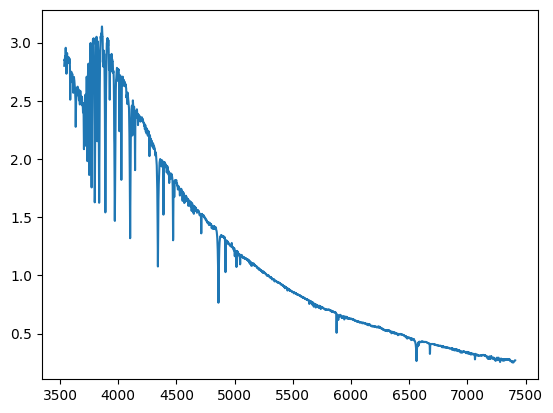

In [6]:
plt.plot(final_wave, flux_list[0][:-1])

In [7]:
target_flux_list = flux_list

### Preparing the data

Splitting the data 

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(flux_list, flux_list, test_size= 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state= 42)

Removing the name tags for the final data

In [9]:
def remove_nametags(array):
    '''
    Removes the last name tag in the 2D spectral data
    '''
    for i in range(len(array)):
        array[i] = array[i][:-1]
        array[i] = np.array(array[i])
    array = np.array(array)

    return array

In [10]:
X_final_train, X_final_val, X_final_test = remove_nametags(X_train), remove_nametags(X_val), remove_nametags(X_test)
y_final_train, y_final_val, y_final_test = remove_nametags(y_train), remove_nametags(y_val), remove_nametags(y_test)

In [11]:
print(X_final_train.shape, X_final_val.shape, X_final_test.shape)
print(y_final_train.shape, y_final_val.shape, y_final_test.shape)

(788, 4306) (98, 4306) (99, 4306)
(788, 4306) (98, 4306) (99, 4306)


Switching from CPU to CUDA cores : 

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Converting each data point vector to a rank 1 tensor

In [13]:
X_train_tensor = torch.tensor(X_final_train, dtype= torch.float32).to(device= device)       # converting the input data to tensor , in out case , each input datapoint is a rank 1 tensor (vector)
y_train_tensor = torch.tensor(y_final_train, dtype= torch.float32).to(device= device)

X_val_tensor = torch.tensor(X_final_val, dtype= torch.float32).to(device= device)
y_val_tensor = torch.tensor(y_final_val, dtype= torch.float32).to(device= device)

X_test_tensor = torch.tensor(X_final_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_final_test, dtype=torch.float32).to(device)

Creating a joint pair and wrapping the dataset to enable mini-batch training : 

In [14]:
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32)    
val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

### Creating the VAE model

In [15]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim = 4306, latent_dim = 16):
        super(VariationalAutoencoder, self).__init__()

        # creating the feed forward network    
        # Encoder

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024,256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # Decoder

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

        # initialzing the forward feed 

    def forward(self, x):       
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded
        

In [16]:
model = VariationalAutoencoder()
model.to(device=device)

VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4306, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=4306, bias=True)
  )
)

Setting the ADAM optimizer

In [17]:
optimizer = optim.Adam(model.parameters(), lr= 0.01)

loss_fn = nn.MSELoss()      # MSE as the loss functon

#### Training loop and optimizing model parameters using backpropagation and ADAM :

In [18]:
loss_list = []
val_list = []

for epoch in range(1, 251):
    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss
    
    print(f"Epoch number : {epoch}, loss = {running_loss}")

    if running_loss < 0.02:     # setting up a threshold for epochs (early stopping)
        break

    model.eval()
    val_loss = 0.0

    with torch.no_grad():       # no backward propagation
        for x_val_batch, y_val_batch in val_loader:

            output = model(x_val_batch)

            loss = loss_fn(output, y_val_batch)

            val_loss += loss
        
    print(f"Epoch number : {epoch}, val_loss = {val_loss}")

    loss_list.append(running_loss)
    val_list.append(val_loss)


Epoch number : 1, loss = 18840.779296875
Epoch number : 1, val_loss = 1.9366077184677124
Epoch number : 2, loss = 9.37959098815918
Epoch number : 2, val_loss = 0.8970022797584534
Epoch number : 3, loss = 48.3292236328125
Epoch number : 3, val_loss = 1.0682828426361084
Epoch number : 4, loss = 6.120036602020264
Epoch number : 4, val_loss = 0.9996522665023804
Epoch number : 5, loss = 4.801355838775635
Epoch number : 5, val_loss = 0.7321760654449463
Epoch number : 6, loss = 4.225522041320801
Epoch number : 6, val_loss = 0.7025168538093567
Epoch number : 7, loss = 4.157369136810303
Epoch number : 7, val_loss = 0.6899842619895935
Epoch number : 8, loss = 4.117158889770508
Epoch number : 8, val_loss = 0.6903205513954163
Epoch number : 9, loss = 4.148163318634033
Epoch number : 9, val_loss = 0.7005468606948853
Epoch number : 10, loss = 4.122377872467041
Epoch number : 10, val_loss = 0.6843975186347961
Epoch number : 11, loss = 4.070109844207764
Epoch number : 11, val_loss = 0.6729497909545898

In [21]:
learning_list = []
for i in range(len(loss_list)):
    learning_list.append(loss_list[i].item())

validation_list = []

for i in range(len(val_list)):
    validation_list.append(val_list[i].item())

In [22]:
validation_list

[1.9366077184677124,
 0.8970022797584534,
 1.0682828426361084,
 0.9996522665023804,
 0.7321760654449463,
 0.7025168538093567,
 0.6899842619895935,
 0.6903205513954163,
 0.7005468606948853,
 0.6843975186347961,
 0.6729497909545898,
 0.6524302363395691,
 0.662498950958252,
 0.5998716354370117,
 0.5516603589057922,
 0.3143198788166046,
 0.1672990918159485,
 0.14312869310379028,
 0.1194286048412323,
 0.10978908091783524,
 0.09923571348190308,
 0.08586620539426804,
 0.07335866987705231,
 0.06141413748264313,
 0.058826249092817307,
 0.05381346121430397,
 0.0504438579082489,
 0.06675642728805542,
 0.06777199357748032,
 0.049632541835308075,
 0.04665403813123703,
 0.050000015646219254,
 0.04975060373544693,
 0.04835544899106026,
 0.04974404349923134,
 0.045515093952417374,
 0.04523707181215286,
 0.045746155083179474,
 0.04722873494029045,
 0.04698016867041588,
 0.04535478353500366,
 0.04520907253026962,
 0.0435963049530983,
 0.042800333350896835,
 0.04365072399377823,
 0.04105314239859581,
 0.

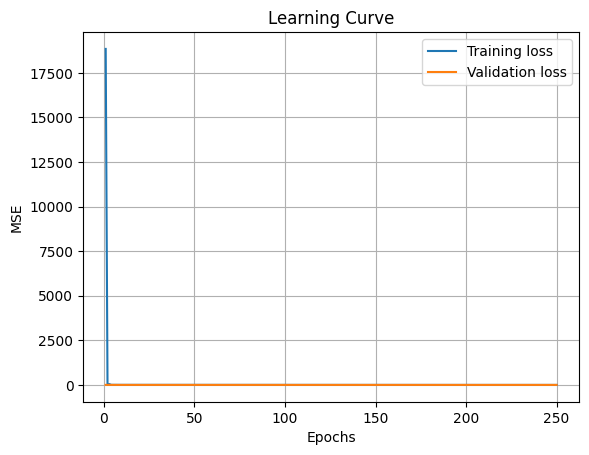

In [23]:
sns.lineplot(x = np.linspace(1,len(learning_list), len(learning_list)), y = learning_list, label = "Training loss")
sns.lineplot(x = np.linspace(1, len(validation_list), len(validation_list)), y = validation_list, label = "Validation loss")
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid()